# DL подход

**Идея**

К имеющемуся набору признаков применить модели на основе DL

## Data & Libs

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from pandas import IndexSlice as idx
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(42)
np.random.seed(42)

# Выбор cpu или gpu
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Загрузка данных

In [2]:
df = pd.read_csv(r"..\data\df_tickers.csv", header=[0, 1], index_col=0).sort_index(axis=1)
df.index = pd.to_datetime(df.index, format="%Y-%m-%d")

ts_df: pd.DataFrame = df.loc[:, idx[:, "close"]].dropna().droplevel(level=1, axis=1)

rate = pd.read_pickle("../data/rate.pkl")["CB"]

curr = pd.read_csv("../data/currencies.csv", index_col=0)
curr.index = curr.index.str.extract(r"(\d{4}-\d{2}-\d{2})")[0]
curr.index.name = "date"
curr.index = pd.to_datetime(curr.index, format="%Y-%m-%d")

df_futures: pd.DataFrame = pd.read_pickle("../data/df_futures.pkl") \
    .dropna() \
    .rename({"TRADEDATE": "date", "CLOSE": "BR"}, axis=1)
df_futures = df_futures.loc[df_futures.groupby("date")["delta_days"].idxmin()]
df_futures = df_futures.set_index("date")["BR"]

res_df = ts_df \
    .merge(rate, "left", left_index=True, right_index=True) \
    .merge(curr, "left", left_index=True, right_index=True) \
    .merge(df_futures, "left", left_index=True, right_index=True)

data = res_df.copy()
data = data.interpolate(method="linear", limit_direction="forward", limit_area="inside", limit=3)

target_col = "LKOH"
feature_cols = ["rate", "Доллар", "Евро", "Юань", "BR"]

def create_time_features(
    df: pd.DataFrame,
    return_new_colnames: bool = True,
    exclude: str | list | None = "dayofweek"
):
    df_cols = df.columns
    df = df.copy()

    # Основные временные признаки
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["dayofweek"] = df.index.dayofweek
    df["quarter"] = df.index.quarter
    df["days_since_start"] = (df.index - df.index.min()).days

    # Синус и косинус для цикличных признаков (месяцы, дни недели)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    if exclude is not None:
        df = df.drop(exclude, axis=1)

    if return_new_colnames:
        return df, df.columns.difference(df_cols).to_list()
    return df

data_features, time_features = create_time_features(data)

Немного упрощенная версия функции, которая создает фичи (в моделях будут не нужны лаги):

(* взято из ML части)

In [3]:
ma_windows = (7, 14, 30)
ewm_windows = (7, 14, 30)
vol_windows = (7, 14, 30)

def create_features(
    df: pd.DataFrame,
    target_column: str,
    ma_windows: tuple | list = ma_windows,
    ewm_windows: tuple | list = ewm_windows,
    vol_windows: tuple | list = vol_windows,
    return_new_colnames: bool = True,
    verbose: bool = True
) -> pd.DataFrame | tuple[pd.DataFrame, list]:

    original_cols = df.columns.tolist()
    base_df = df.copy()

    all_features = {}

    def create_ma_features():
        ma_dfs = {}
        for window in ma_windows:
            ma_dfs[f"{target_column}_ma_{window}"] = base_df[target_column].rolling(window=window, closed="left").mean()
        return ma_dfs
    ma_dfs = create_ma_features()
    all_features.update(ma_dfs)

    def create_ewm_features():
        ewm_dfs = {}
        for window in ewm_windows:
            ewm_dfs[f"{target_column}_ema_{window}"] = base_df[target_column].ewm(span=window, adjust=False).mean()
        return ewm_dfs
    ewm_dfs = create_ewm_features()
    all_features.update(ewm_dfs)

    def create_vol_features():
        vol_dfs = {}
        for window in vol_windows:
            vol_dfs[f"{target_column}_vol_{window}"] = base_df[target_column].rolling(window=window, closed="left").std()
        return vol_dfs
    vol_dfs = create_vol_features()
    all_features.update(vol_dfs)

    def create_pct_change_features():
        pct_change_dfs = {}
        for lag in range(1, 6):
            pct_change_dfs[f"{target_column}_pct_change_{lag}"] = base_df[target_column].pct_change(periods=lag)
        return pct_change_dfs
    all_features.update(create_pct_change_features())

    def create_roc_features():
        roc_dfs = {}
        for window in ma_windows:
            roc_dfs[f"{target_column}_roc_{window}"] = (base_df[target_column] - base_df[target_column].shift(window)) / base_df[target_column].shift(window) * 100
        return roc_dfs
    all_features.update(create_roc_features())

    def create_momentum_features():
        momentum_dfs = {}
        for window in ma_windows:
            momentum_dfs[f"{target_column}_momentum_{window}"] = base_df[target_column] - base_df[target_column].shift(window)
        return momentum_dfs
    all_features.update(create_momentum_features())

    def create_rsi_features():
        rsi_dfs = {}
        delta = base_df[target_column].diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)

        for window in (14, 21):
            avg_gain = gain.rolling(window=window, closed="left").mean()
            avg_loss = loss.rolling(window=window, closed="left").mean()
            rs = avg_gain / avg_loss
            rsi_dfs[f"{target_column}_rsi_{window}"] = 100 - (100 / (1 + rs))
        return rsi_dfs
    all_features.update(create_rsi_features())

    def create_macd_features():
        macd_dfs = {}
        ema_12 = base_df[target_column].ewm(span=12, adjust=False).mean()
        ema_26 = base_df[target_column].ewm(span=26, adjust=False).mean()
        macd = ema_12 - ema_26
        macd_signal = macd.ewm(span=9, adjust=False).mean()

        macd_dfs[f"{target_column}_macd"] = macd
        macd_dfs[f"{target_column}_macd_signal"] = macd_signal
        macd_dfs[f"{target_column}_macd_hist"] = macd - macd_signal
        return macd_dfs
    all_features.update(create_macd_features())

    def create_bb_features():
        bb_dfs = {}
        for window in ma_windows:
            ma_series = ma_dfs[f"{target_column}_ma_{window}"]
            vol_series = vol_dfs[f"{target_column}_vol_{window}"]

            bb_upper = ma_series + 2 * vol_series
            bb_lower = ma_series - 2 * vol_series
            bb_width = (bb_upper - bb_lower) / ma_series
            bb_pct = (base_df[target_column] - bb_lower) / (bb_upper - bb_lower)

            bb_dfs[f"{target_column}_bb_upper_{window}"] = bb_upper
            bb_dfs[f"{target_column}_bb_lower_{window}"] = bb_lower
            bb_dfs[f"{target_column}_bb_width_{window}"] = bb_width
            bb_dfs[f"{target_column}_bb_pct_{window}"] = bb_pct
        return bb_dfs
    all_features.update(create_bb_features())

    def create_stat_features():
        stat_dfs = {}
        for window in [30]:
            stat_dfs[f"{target_column}_skew_{window}"] = base_df[target_column].rolling(window=window, closed="left").apply(lambda x: stats.skew(x))
            stat_dfs[f"{target_column}_kurt_{window}"] = base_df[target_column].rolling(window=window, closed="left").apply(lambda x: stats.kurtosis(x))

            rolling_max = base_df[target_column].rolling(window=window, closed="left").max()
            rolling_min = base_df[target_column].rolling(window=window, closed="left").min()

            stat_dfs[f"{target_column}_max_{window}"] = rolling_max
            stat_dfs[f"{target_column}_min_{window}"] = rolling_min
            stat_dfs[f"{target_column}_range_{window}"] = rolling_max - rolling_min

            q25 = base_df[target_column].rolling(window=window, closed="left").quantile(0.25)
            q75 = base_df[target_column].rolling(window=window, closed="left").quantile(0.75)

            stat_dfs[f"{target_column}_q25_{window}"] = q25
            stat_dfs[f"{target_column}_q75_{window}"] = q75
            stat_dfs[f"{target_column}_iqr_{window}"] = q75 - q25
        return stat_dfs
    all_features.update(create_stat_features())

    def create_zscore_features():
        zscore_dfs = {}
        for window in ma_windows:
            zscore_dfs[f"{target_column}_zscore_{window}"] = (base_df[target_column] - ma_dfs[f"{target_column}_ma_{window}"]) / vol_dfs[f"{target_column}_vol_{window}"]
        return zscore_dfs
    all_features.update(create_zscore_features())

    def create_dist_features():
        dist_dfs = {}
        for window in ma_windows:
            ma_series = ma_dfs[f"{target_column}_ma_{window}"]
            dist_dfs[f"{target_column}_dist_ma_{window}"] = base_df[target_column] - ma_series
            dist_dfs[f"{target_column}_dist_pct_ma_{window}"] = (base_df[target_column] / ma_series - 1) * 100
        return dist_dfs
    all_features.update(create_dist_features())

    def create_cross_features():
        cross_dfs = {}
        for fast_window, slow_window in [(7, 14), (14, 30)]:
            if f"{target_column}_ma_{fast_window}" in ma_dfs and f"{target_column}_ma_{slow_window}" in ma_dfs:
                cross_dfs[f"{target_column}_cross_{fast_window}_{slow_window}"] = ma_dfs[f"{target_column}_ma_{fast_window}"] - ma_dfs[f"{target_column}_ma_{slow_window}"]
        return cross_dfs
    all_features.update(create_cross_features())

    def create_williams_features():
        williams_dfs = {}
        for window in ma_windows:
            highest_high = base_df[target_column].rolling(window=window, closed="left").max()
            lowest_low = base_df[target_column].rolling(window=window, closed="left").min()
            williams_dfs[f"{target_column}_williams_{window}"] = -100 * (highest_high - base_df[target_column]) / (highest_high - lowest_low)
        return williams_dfs
    all_features.update(create_williams_features())

    def create_smooth_features():
        smooth_dfs = {}
        for window in ma_windows:
            smooth_dfs[f"{target_column}_ma_of_ma_{window}"] = ma_dfs[f"{target_column}_ma_{window}"].rolling(window=window, closed="left").mean()
            smooth_dfs[f"{target_column}_ema_of_ema_{window}"] = ewm_dfs[f"{target_column}_ema_{window}"].ewm(span=window, adjust=False).mean()
        return smooth_dfs
    all_features.update(create_smooth_features())

    def create_trend_features():
        trend_dfs = {}
        for window in ma_windows:
            trend_dfs[f"{target_column}_trend_strength_{window}"] = np.abs(ma_dfs[f"{target_column}_ma_{window}"].diff(periods=window)) / vol_dfs[f"{target_column}_vol_{window}"]
        return trend_dfs
    all_features.update(create_trend_features())

    def create_fft_features():
        fft_dfs = {}
        for window in [30, 60]:
            if len(base_df) >= window:
                fft_dfs[f"{target_column}_fft_dominant_{window}"] = base_df[target_column].rolling(window=window, closed="left").apply(
                    lambda x: np.abs(np.fft.fft(x - np.mean(x)))[1:window//2].argmax() + 1 if len(x) == window else np.nan
                )
        return fft_dfs
    all_features.update(create_fft_features())

    features_df = pd.DataFrame(all_features, index=base_df.index)
    result_df = pd.concat([base_df, features_df], axis=1)

    if verbose:
        print(f"Total new features created: {len(features_df.columns)}")

    if return_new_colnames:
        new_cols = [col for col in result_df.columns if col not in original_cols]
        return result_df, new_cols
    else:
        return result_df

In [4]:
df_features_ext, _ = create_features(data_features, "LKOH", verbose=False)
df_features_ext = df_features_ext.dropna()
df_features_ext_lite = df_features_ext.drop(["ROSN", "SIBN", "SNGS", "TATN", "rate", "Доллар", "Евро", "Юань", "BR"], axis=1)

## LSTM

In [5]:
# Класс для создания датасета PyTorch
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        self.y = torch.tensor(y, dtype=torch.float32).to(DEVICE)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

# Модель LSTM
class LSTMForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM слой
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        # Полносвязный слой
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Инициализация скрытых состояний
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(DEVICE)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(DEVICE)

        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

# Функция обучения модели
def fit_model(model, train_loader, val_loader, loss_fn, optimizer, epochs=100, patience=15, scheduler=None):
    model.to(DEVICE)

    train_losses, val_losses = [], []
    best_val = float("inf")
    stop_count = 0

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0

        # Обучение
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch.unsqueeze(1))
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        train_losses.append(epoch_train_loss / len(train_loader))

        # Валидация
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                predictions = model(X_batch)
                loss = loss_fn(predictions, y_batch.unsqueeze(1))
                epoch_val_loss += loss.item()
        val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(val_loss)

        # Обновление scheduler'а
        if scheduler is not None:
            scheduler.step(val_loss)

        # Сохраняем модель, если стало лучше
        if val_loss < best_val:
            best_val = val_loss
            stop_count = 0
            torch.save(model.state_dict(), "best_lstm_model.pt")
        else:
            stop_count += 1
            if stop_count >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}")

    # Загружаем лучшую модель
    model.load_state_dict(torch.load("best_lstm_model.pt"))
    return model, train_losses, val_losses

Подход получения прогнозов возьмем, как в случае с CatBoost: будем создавать сдвинутую вперед переменную и использовать ее в качестве целевой.

Это позволит избежать накопления ошибки из-за отстутствия данных по другим переменным

In [6]:
# Создание обучающих последовательностей
def make_sequences(data, window_size, horizon):
    features, labels = [], []
    for i in range(len(data) - window_size - horizon):
        features.append(data[i:i+window_size])
        labels.append(data[i+window_size+horizon, 0])
    return np.array(features), np.array(labels)

# Основная функция для оценки LSTM модели по множеству горизонтов прогнозирования
def lstm_evaluate(
    df, model_class, target_col="LKOH", window_size=30,
    forecast_steps=20, hidden_dim=64, num_layers=2, dropout=0.2,
    batch_size=32, epochs=100, patience=20, train_size=1000, val_ratio=0.1
):
    df_clean = df.copy()

    # Удаление столбца "date" и заполнение пропусков
    if "date" in df_clean.columns:
        df_clean = df_clean.drop(columns=["date"])
    df_clean = df_clean.dropna()

    # Определение размеров обучающей, валидационной и тестовой выборки
    val_size = int(train_size * val_ratio)
    test_size = forecast_steps
    train_data = df_clean.iloc[:train_size-val_size]
    val_data = df_clean.iloc[train_size-val_size:train_size]
    test_data = df_clean.iloc[train_size:train_size+test_size]

    print(f"Train size: {len(train_data)}, Validation size: {len(val_data)}, Test size: {len(test_data)}")

    models = []                                     # Список моделей для каждого горизонта
    predictions = []                                # Список предсказаний
    actual_values = test_data[target_col].values    # Фактические значения для тестовой выборки
    metrics = []                                    # Список метрик для каждого горизонта
    scalers = []                                    # Список масштабировщиков для каждого горизонта

    reordered = [target_col] + [col for col in df_clean.columns if col != target_col]

    # Обучение и прогнозирование на каждом горизонте t+1, t+2, ..., t+n
    for horizon in range(1, forecast_steps + 1):
        print(f"\nTraining model for horizon t+{horizon}:")

        # Масштабирование признаков (MinMaxScaler по всем колонкам)
        scaler = MinMaxScaler()
        all_train_data = df_clean.iloc[:train_size]
        scaler.fit(all_train_data[reordered].values)
        train_scaled = scaler.transform(train_data[reordered].values)
        val_scaled = scaler.transform(val_data[reordered].values)
        scalers.append(scaler)

        # Создание обучающих и валидационных последовательностей
        X_train, y_train = make_sequences(train_scaled, window_size, horizon-1)
        X_val, y_val = make_sequences(val_scaled, window_size, horizon-1)

        # Оборачиваем в PyTorch Dataset и DataLoader
        train_dataset = TimeSeriesDataset(X_train, y_train)
        val_dataset = TimeSeriesDataset(X_val, y_val)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        # Создание модели
        input_dim = X_train.shape[2]
        model = model_class(input_dim, hidden_dim, num_layers, 1, dropout).to(DEVICE)
        loss_fn = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=patience//2)

        # Обучение модели
        model, train_losses, val_losses = fit_model(
            model, train_loader, val_loader, loss_fn, optimizer,
            epochs=epochs, patience=patience, scheduler=scheduler
        )
        models.append(model)

        # Прогноз на тестовом горизонте
        last_sequence = val_scaled[-window_size:]
        model.eval()
        with torch.no_grad():
            seq_tensor = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            prediction = model(seq_tensor).cpu().item()

        # Обратное масштабирование
        dummy = np.zeros((1, scaler.n_features_in_))
        dummy[0, 0] = prediction
        prediction_rescaled = scaler.inverse_transform(dummy)[0, 0]
        predictions.append(prediction_rescaled)

        # Расчет метрик
        if horizon <= len(actual_values):
            actual = actual_values[horizon-1]
            mse = (prediction_rescaled - actual) ** 2
            mae = abs(prediction_rescaled - actual)
            mape = abs((prediction_rescaled - actual) / actual) * 100 if actual != 0 else np.inf
            metrics.append({"mse": mse, "mae": mae, "mape": mape})
            print(f"Metrics - Sqr error: {mse:.2f}, Abs error: {mae:.2f}, Abs % error: {mape:.2f}%")

    # Создание DataFrame с предсказаниями и фактическими значениями
    test_predictions_df = pd.DataFrame(
        {"Predicted (target shift)": predictions[:len(test_data)],
         "Real": test_data[target_col].values[:len(predictions)]},
        index=test_data.index[:len(predictions)]
    )

    # Визуализация предсказаний
    test_predictions_df.plot()
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Расчет средних метрик по всем горизонтам
    metrics_df = pd.DataFrame(metrics)
    print("\nAverage Metrics Across All Horizons:")
    print(f"RMSE: {np.sqrt(metrics_df['mse'].mean()):.2f}")
    print(f"MAE: {metrics_df['mae'].mean():.2f}")
    print(f"MAPE: {metrics_df['mape'].mean():.2f}%")

    return models, test_predictions_df, metrics_df

In [ ]:
# models, predictions_df, metrics_df = lstm_evaluate(
#     df_features_ext_lite,
#     LSTMForecaster,
#     target_col="LKOH",
#     window_size=30,
#     forecast_steps=20,
#     train_size=1000
# )

Полученные результаты значительно лучше результатов `CatBoost` - причем работает все значительно быстрее!

## Дополнение

In [13]:
def multiple_lstm_evaluations(
    df, model_class, n_runs=100, min_train_size=300, forecast_steps=20, **kwargs
):
    np.random.seed(42)  # Для воспроизводимости
    max_split_point = len(df) - forecast_steps
    all_metrics = []
    all_predictions = []

    # Генерация случайных точек разбиения
    split_points = np.random.randint(min_train_size, max_split_point, size=n_runs)

    for i, split_point in enumerate(split_points, 1):
        print(f"\n=== Run {i}/{n_runs} | Split point: {split_point} ===")
        df_subset = df.iloc[:split_point + forecast_steps].copy()

        try:
            _, predictions_df, metrics_df = lstm_evaluate(
                df_subset,
                model_class=model_class,
                train_size=split_point,
                forecast_steps=forecast_steps,
                **kwargs
            )
            metrics_df["run"] = i
            metrics_df["split_point"] = split_point
            predictions_df["run"] = i
            predictions_df["split_point"] = split_point

            all_metrics.append(metrics_df)
            all_predictions.append(predictions_df)

        except Exception as e:
            print(f"⚠️ Error at run {i} (split={split_point}): {e}")
            continue

    all_metrics_df = pd.concat(all_metrics, ignore_index=True)
    all_predictions_df = pd.concat(all_predictions, ignore_index=False)

    # Средние метрики по всем прогонам
    print("\n==== Average Metrics Across All Runs ====")
    print(all_metrics_df.groupby("run")[["mse", "mae", "mape"]].mean().mean())

    return all_metrics_df, all_predictions_df


In [ ]:
metrics_all, preds_all = multiple_lstm_evaluations(
    df_features_ext_lite,
    LSTMForecaster,
    target_col="LKOH",
    window_size=30,
    forecast_steps=10,
    hidden_dim=64,
    num_layers=2,
    dropout=0.2,
    batch_size=32,
    epochs=100,
    patience=10,
    n_runs=100
)

In [20]:
avg_metrics = metrics_all[["mse", "mae", "mape"]].mean()
print("Среднее по всем фолдам и горизонтам:")
print(f"RMSE: {np.sqrt(avg_metrics['mse']):.4f}")
print(f"MAE:  {avg_metrics['mae']:.4f}")
print(f"MAPE: {avg_metrics['mape']:.2f}%")

Среднее по всем фолдам и горизонтам:
RMSE: 330.7537
MAE:  227.8317
MAPE: 5.18%


In [21]:
avg_by_horizon = metrics_all.groupby(metrics_all.index % 20 + 1)[["mse", "mae", "mape"]].mean()
avg_by_horizon.index.name = "Horizon (t+)"
print("Средние метрики по каждому горизонту:")
display(avg_by_horizon)


Средние метрики по каждому горизонту:


,mse,mae,mape
Horizon (t+),,,
1,146444.119370,243.065493,5.266343
2,115795.417916,230.352710,5.393010
3,138768.750058,255.345471,5.972218
4,136979.514118,265.188368,6.225286
5,138320.183970,254.082877,5.870220
6,117334.550102,255.034230,6.088700
7,147856.842671,267.396684,6.328068
8,148082.804376,267.264298,6.382962
9,155593.229064,272.861942,6.193119


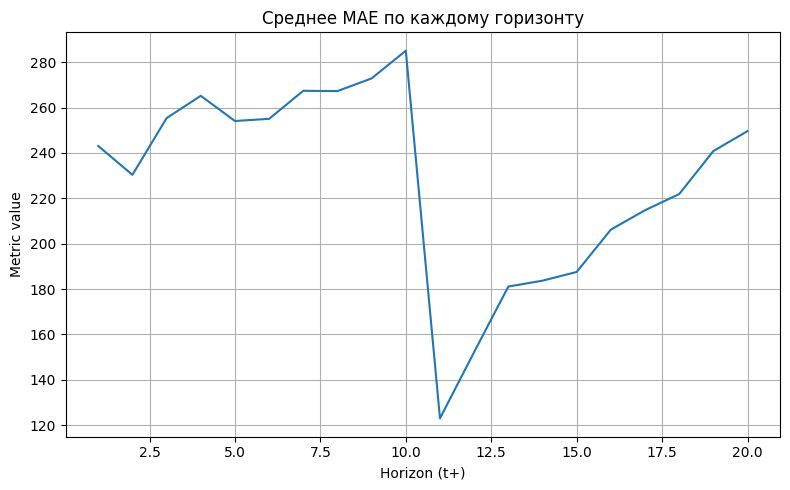

In [28]:
plt.figure(figsize=(8,5))

avg_by_horizon["mae"].plot(title="Среднее MAE по каждому горизонту", grid=True)
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()